<a href="https://colab.research.google.com/github/siddharth2004agrawal/AiProject1/blob/AiModules%2Fmodule-3/module2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = 'car_evaluation.csv'

In [ ]:
df = pd.read_csv(data,header=None)

In [ ]:
col_names = ['buying','maint','doors','persons','lug_boot','safety','class']

In [ ]:
df.columns = col_names

In [ ]:
col_names

['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

In [ ]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [ ]:
x = df.drop(['class'],axis=1)
y = df['class']


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.33,random_state=42)

In [ ]:
x_train.shape,x_test.shape

((1157, 6), (571, 6))

In [ ]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.9 MB/s eta 0:00:00


In [ ]:
 import category_encoders as ce
 encoder = ce.OrdinalEncoder(cols=['buying','maint','doors','persons','lug_boot','safety'])
 x_train = encoder.fit_transform(x_train)
 x_test = encoder.transform(x_test)

# decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
clf_gini = DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
clf_gini.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [ ]:
y_pred = clf_gini.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
print('Model accuracy score with criterion gini index: {0:0.4f}'.format(accuracy_score(y_test,y_pred)))

Model accuracy score with criterion gini index: 0.8021


In [ ]:
print('Training set accuracy: {0:0.4f}'.format(clf_gini.score(x_train,y_train)))

Training set accuracy: 0.7865


[Text(0.4, 0.875, 'x[5] <= 1.5\ngini = 0.455\nsamples = 1157\nvalue = [255, 49, 813, 40]'),
 Text(0.2, 0.625, 'gini = 0.0\nsamples = 386\nvalue = [0, 0, 386, 0]'),
 Text(0.30000000000000004, 0.75, 'True  '),
 Text(0.6, 0.625, 'x[3] <= 2.5\ngini = 0.577\nsamples = 771\nvalue = [255, 49, 427, 40]'),
 Text(0.5, 0.75, '  False'),
 Text(0.4, 0.375, 'x[0] <= 2.5\ngini = 0.631\nsamples = 525\nvalue = [255.0, 49.0, 181.0, 40.0]'),
 Text(0.2, 0.125, 'gini = 0.496\nsamples = 271\nvalue = [124, 0, 147, 0]'),
 Text(0.6, 0.125, 'gini = 0.654\nsamples = 254\nvalue = [131, 49, 34, 40]'),
 Text(0.8, 0.375, 'gini = 0.0\nsamples = 246\nvalue = [0, 0, 246, 0]')]

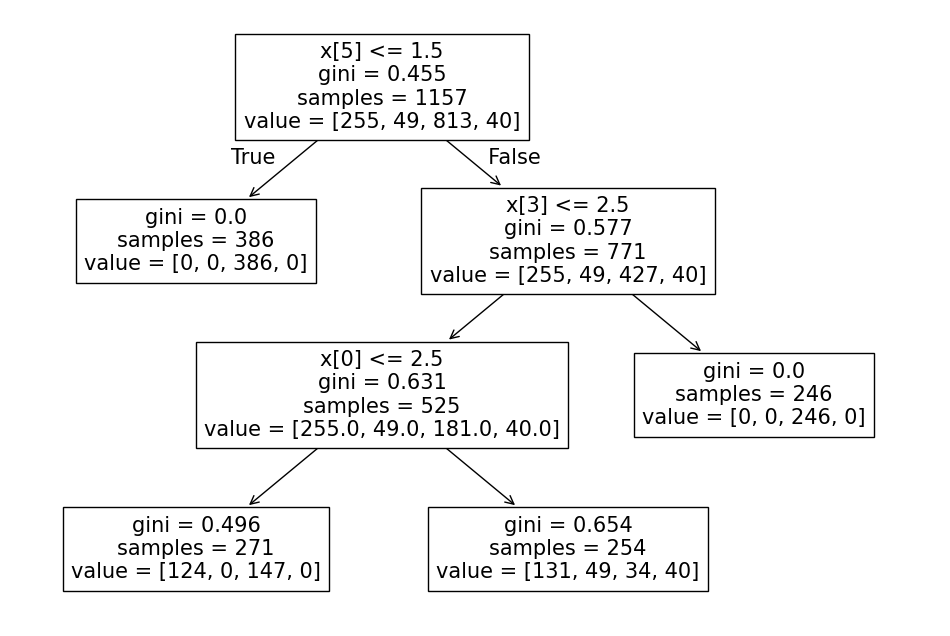

In [ ]:
plt.figure(figsize=(12,8))
from sklearn import tree
tree.plot_tree(clf_gini.fit(x_train,y_train))


In [ ]:
import sqlite3 as sq3
import pandas.io.sql as pds
import pandas as pd

In [ ]:
path='/content/classic_rock.db'

In [ ]:
con=sq3.connect(path)

In [ ]:
query="SELECT * FROM rock_songs where PlayCount>100;"

In [ ]:
observations=pds.read_sql(query,con)

In [ ]:
observations.head(50)

,Song,Artist,Release_Year,PlayCount
0,You Shook Me All Night Long,AC/DC,1980.0,138
1,Dream On,Aerosmith,1973.0,142
2,Sweet Emotion,Aerosmith,1975.0,141
3,Walk This Way,Aerosmith,1975.0,106
4,Paranoid,Black Sabbath,1970.0,105
5,Burnin' for You,Blue Oyster Cult,1981.0,107
6,More Than a Feeling,Boston,1976.0,134
7,Peace of Mind,Boston,1976.0,132
8,I Want You to Want Me,Cheap Trick,1977.0,110
9,Hotel California,Eagles,1976.0,109


In [ ]:
query="select Artist,Release_Year,count(*) as num_songs,avg(PlayCount) As avg_plays from rock_songs group by Artist,Release_Year order by num_songs desc;"

In [ ]:
observations=pds.read_sql(query,con)

In [ ]:
observations.head(50)

,Artist,Release_Year,num_songs,avg_plays
0,The Beatles,1967.0,23,6.565217
1,Led Zeppelin,1969.0,18,21.000000
2,The Beatles,1965.0,15,3.800000
3,The Beatles,1968.0,13,13.000000
4,The Beatles,1969.0,13,15.000000
5,Led Zeppelin,1970.0,12,13.166667
6,Led Zeppelin,1975.0,12,14.166667
7,Pink Floyd,1979.0,11,41.454545
8,Pink Floyd,1973.0,10,29.100000
9,The Doors,1967.0,10,28.900000


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
path='/content/IOT-temp.csv'

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from sklearn.metrics import (classification_report,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,RocCurveDisplay)

In [ ]:
 from google.colab import files

In [ ]:
uploaded = files.upload()

Saving IOT-temp.csv to IOT-temp (1).csv


In [ ]:
filename = list(uploaded.keys())[0]

In [ ]:
df = pd.read_csv(filename)

In [ ]:
print('Shape:',df.shape)

Shape: (97606, 5)


In [ ]:
df.head()

,id,room_id/id,noted_date,temp,out/in
0,__export__.temp_log_196134_bd201015,Room Admin,08-12-2018 09:30,29,In
1,__export__.temp_log_196131_7bca51bc,Room Admin,08-12-2018 09:30,29,In
2,__export__.temp_log_196127_522915e3,Room Admin,08-12-2018 09:29,41,Out
3,__export__.temp_log_196128_be0919cf,Room Admin,08-12-2018 09:29,41,Out
4,__export__.temp_log_196126_d30b72fb,Room Admin,08-12-2018 09:29,31,In


In [ ]:
print('== Data Types ===')

== Data Types ===


In [ ]:
print(df.dtypes)

id            object
room_id/id    object
noted_date    object
temp           int64
out/in        object
dtype: object


In [ ]:
print('=== Missing Values ===')

=== Missing Values ===


In [ ]:
print(df.isnull().sum())

id            0
room_id/id    0
noted_date    0
temp          0
out/in        0
dtype: int64


In [ ]:
print('=== Label Distribution ===')

=== Label Distribution ===


In [ ]:
print(df['out/in'].value_counts())

out/in
Out    77261
In     20345
Name: count, dtype: int64


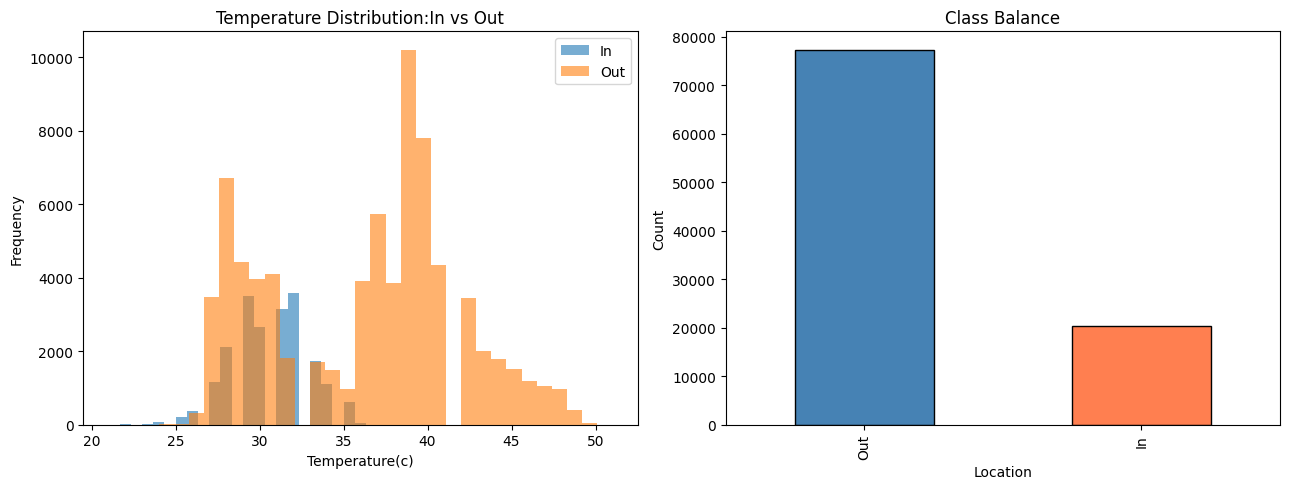

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(13, 5))
df.groupby('out/in')['temp'].plot(kind='hist',bins=30,alpha=0.6,ax=axes[0],legend=True)
axes[0].set_title('Temperature Distribution:In vs Out')
axes[0].set_xlabel('Temperature(c)')
df['out/in'].value_counts().plot(kind='bar',ax=axes[1],color = ['steelblue','coral'],edgecolor='black')
axes[1].set_title('Class Balance')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
df['noted_date'] = pd.to_datetime(df['noted_date'],dayfirst = True,errors='coerce')

In [ ]:
df['hour'] = df['noted_date'].dt.hour

In [ ]:
df['day_of_week'] = df['noted_date'].dt.dayofweek

In [ ]:
df['month'] = df['noted_date'].dt.month

# encode the target label (in=0, Out=1)

In [ ]:
le= LabelEncoder()

In [ ]:
df['label']=le.fit_transform(df['out/in'])

In [ ]:
print('Label mapping:',dict(zip(le.classes_,le.transform(le.classes_))))

Label mapping: {'In': np.int64(0), 'Out': np.int64(1)}


In [ ]:
df[['temp','hour','day_of_week','month','label']].head()

,temp,hour,day_of_week,month,label
0,29,9,5,12,0
1,29,9,5,12,0
2,41,9,5,12,1
3,41,9,5,12,1
4,31,9,5,12,0


In [ ]:
FEATURES = ['temp','hour','day_of_week','month']

In [ ]:
TARGET = 'label'

In [ ]:
clean = df.dropna(subset=['noted_date'])

In [ ]:
X = clean[FEATURES]
Y = clean[TARGET]

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42,stratify=Y)

In [ ]:
print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

Training samples: 78084
Testing samples: 19522


# train a random forest classifier

In [ ]:
rf = RandomForestClassifier(n_estimators=100,max_depth = 10,random_state=42,n_jobs=-1,class_weight='balanced')

In [ ]:
rf.fit(X_train,Y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_jobs=-1,
                       random_state=42)

In [ ]:
print('Model trained')

Model trained


# Evaluate the model

In [ ]:
y_pred = rf.predict(X_test)
y_pred_prob = rf.predict_proba(X_test)[:,1]


In [ ]:
print('=== Classification Report ===')
print(classification_report(Y_test,y_pred,target_names=le.classes_))
print(f'roc_auc_score: {roc_auc_score(Y_test,y_pred_prob)}')

=== Classification Report ===
              precision    recall  f1-score   support

          In       0.58      0.96      0.72      4069
         Out       0.99      0.81      0.89     15453

    accuracy                           0.84     19522
   macro avg       0.78      0.89      0.81     19522
weighted avg       0.90      0.84      0.86     19522

roc_auc_score: 0.9698284655059699


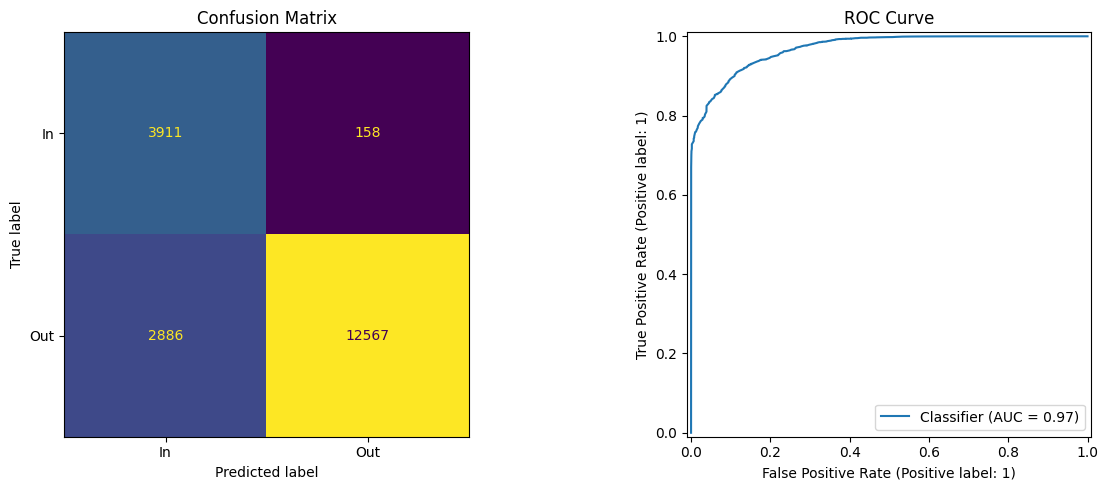

In [ ]:
 fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix')

# ROC Curve
RocCurveDisplay.from_predictions(Y_test, y_pred_prob, ax=axes[1])
axes[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

In [ ]:

!pip3 install keras

In [ ]:
!pip3 install tensorflow --ignore-installed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 85.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.9/71.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB

In [ ]:
!pip3 install wordcloud

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
dataset = pd.read_csv('/content/clickbait_data.csv')

In [ ]:
dataset

,headline,clickbait
0,Should I Get Bings,1
1,Which TV Female Friend Group Do You Belong In,1
2,"The New ""Star Wars: The Force Awakens"" Trailer...",1
3,"This Vine Of New York On ""Celebrity Big Brothe...",1
4,A Couple Did A Stunning Photo Shoot With Their...,1
...,...,...
31995,"To Make Female Hearts Flutter in Iraq, Throw a...",0
31996,"British Liberal Democrat Patsy Calton, 56, die...",0
31997,Drone smartphone app to help heart attack vict...,0
31998,"Netanyahu Urges Pope Benedict, in Israel, to D...",0


In [ ]:
len(dataset)

32000

In [ ]:
dataset['clickbait'].value_counts()

,count
clickbait,
0,16001
1,15999


In [ ]:
x_data = dataset['headline']
y_data = dataset['clickbait']

In [ ]:
x_data['headline'] = x_data.str.lower()
x_data.head()

/tmp/ipykernel_8889/1655964138.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x_data['headline'] = x_data.str.lower()


,headline
0,Should I Get Bings
1,Which TV Female Friend Group Do You Belong In
2,"The New ""Star Wars: The Force Awakens"" Trailer..."
3,"This Vine Of New York On ""Celebrity Big Brothe..."
4,A Couple Did A Stunning Photo Shoot With Their...


In [ ]:
import string
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
  return text.translate(str.maketrans('','',PUNCT_TO_REMOVE))
x_data['headline'] = x_data['headline'].apply(lambda text: remove_punctuation(text))
x_data.head()

,headline
0,Should I Get Bings
1,Which TV Female Friend Group Do You Belong In
2,"The New ""Star Wars: The Force Awakens"" Trailer..."
3,"This Vine Of New York On ""Celebrity Big Brothe..."
4,A Couple Did A Stunning Photo Shoot With Their...
